🔹 Cell 1: Imports + Setup

In [1]:
import os



import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

🔹 Cell 2: Load Data (same as preprocessing output)

In [2]:
df = pd.read_csv("training_data.csv", parse_dates=["date"])

df.head()

,product_id,category,price,competitor_price,discount,units_sold,date,season,day_of_week,stock_available,marketing_spend,customer_rating
0,P039,Sports,1716.21,1805.14,13.9,53,2025-02-08,Winter,Saturday,348,893.21,4.5
1,P021,Electronics,1051.88,1007.69,0.2,37,2024-11-30,Fall,Saturday,468,132.49,4.0
2,P044,Sports,1107.10,1117.92,6.0,41,2025-08-13,Summer,Wednesday,459,470.80,3.6
3,P017,Sports,409.80,422.11,3.3,64,2024-12-03,Winter,Tuesday,406,746.12,4.3
4,P008,Sports,176.89,162.61,2.0,62,2024-01-15,Winter,Monday,497,75.95,4.5


In [3]:
# Feature Engineering (same as preprocessing)

df["price_diff"] = df["price"] - df["competitor_price"]
df["price_ratio"] = df["price"] / df["competitor_price"].clip(lower=1)
df["effective_price"] = df["price"] * (1 - df["discount"] / 100)

df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

df["rolling_demand_7"] = (
    df.groupby("product_id")["units_sold"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

df["log_marketing_spend"] = np.log1p(df["marketing_spend"])

In [4]:
sns.set_theme(style="darkgrid", palette="viridis")

🔹 Cell 5: Price vs Demand

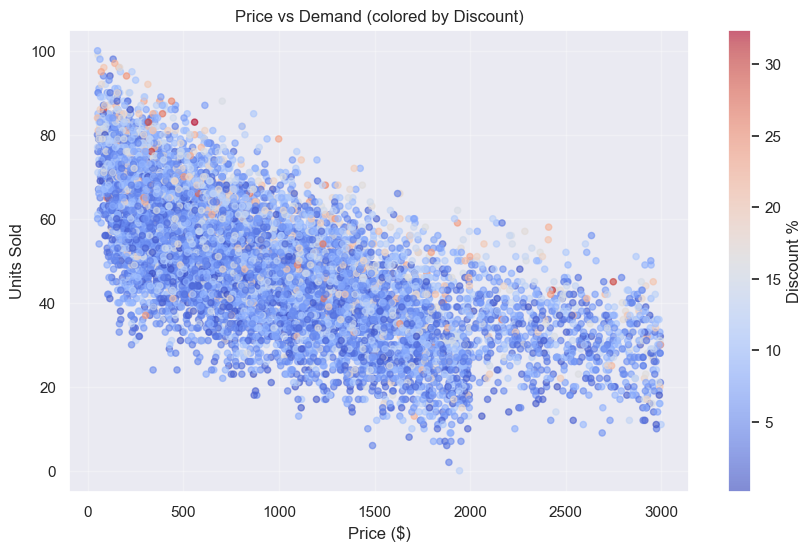

In [5]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df["price"],
    df["units_sold"],
    c=df["discount"],
    cmap="coolwarm",
    alpha=0.6,
    s=20
)

plt.colorbar(scatter, label="Discount %")
plt.xlabel("Price ($)")
plt.ylabel("Units Sold")
plt.title("Price vs Demand (colored by Discount)")
plt.grid(True, alpha=0.3)

plt.show()

### Price vs Demand Analysis

- The plot shows a negative relationship between price and units sold.  
- As the price increases, demand generally decreases.  
- The color gradient represents discount levels:
  - Higher discounts (warmer colors) tend to increase demand  
  - Lower discounts (cooler colors) show comparatively lower sales  
- This indicates that discounts play a key role in influencing demand, even at higher price levels.

🔹 Cell 6: Competitor Price Impact

C:\Users\Dell\AppData\Local\Temp\ipykernel_8868\3407916080.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(bins)["units_sold"].mean()


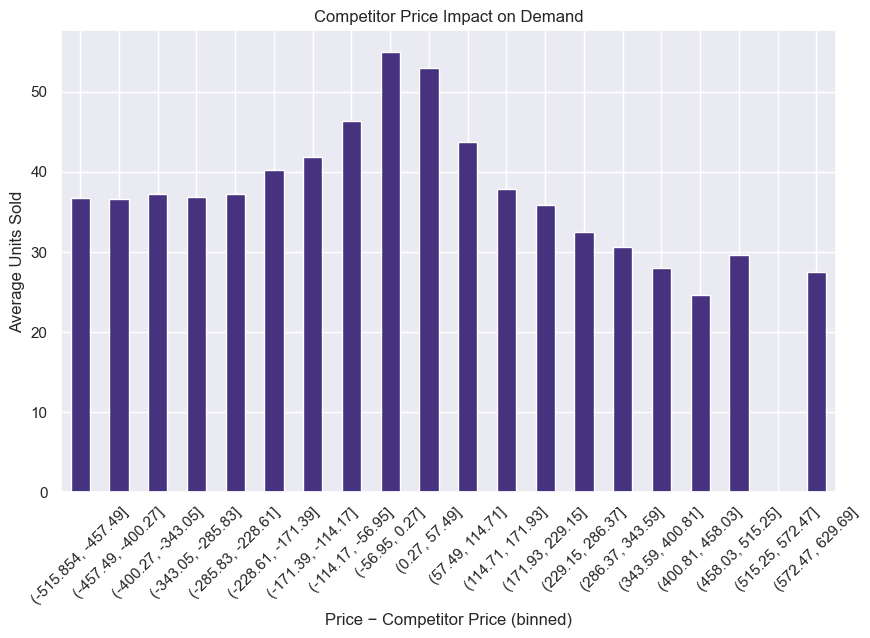

In [6]:
df["price_diff"] = df["price"] - df["competitor_price"]

bins = pd.cut(df["price_diff"], bins=20)
grouped = df.groupby(bins)["units_sold"].mean()

grouped.plot(kind="bar", figsize=(10,6))

plt.xlabel("Price − Competitor Price (binned)")
plt.ylabel("Average Units Sold")
plt.title("Competitor Price Impact on Demand")
plt.xticks(rotation=45)
plt.show()

### Competitor Price Impact on Demand

- The plot shows how the difference between product price and competitor price affects demand.  
- When the product price is close to or slightly lower than the competitor, demand is higher.  
- As the product becomes significantly more expensive than competitors, demand decreases.  
- This indicates that customers are sensitive to relative pricing rather than absolute price.

**Insight:**  
Competitive pricing plays a crucial role in maximizing sales and should be considered in pricing strategies.

🔹 Cell 7: Seasonal Trends

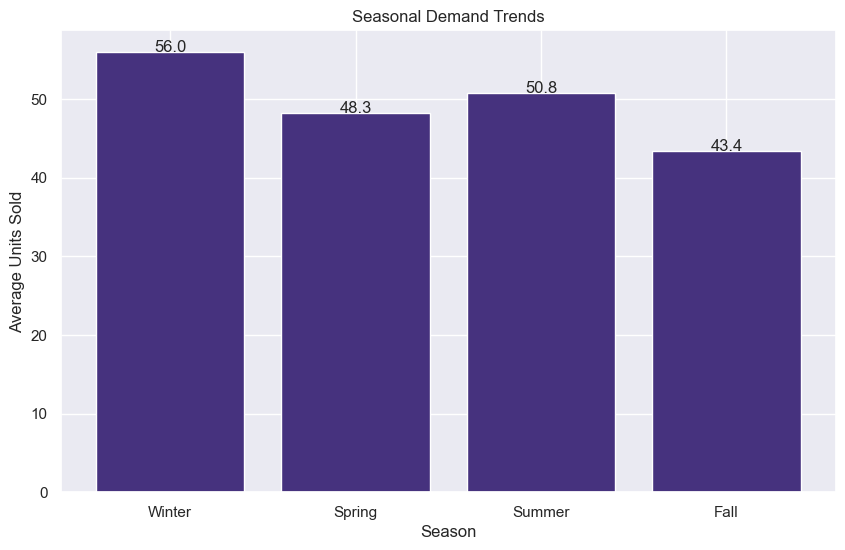

In [7]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_demand = df.groupby("season")["units_sold"].mean().reindex(season_order)

plt.figure(figsize=(10,6))
bars = plt.bar(season_demand.index, season_demand.values)

for bar, val in zip(bars, season_demand.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}", ha="center")

plt.xlabel("Season")
plt.ylabel("Average Units Sold")
plt.title("Seasonal Demand Trends")
plt.show()

🔹 Cell 9: Correlation Heatmap

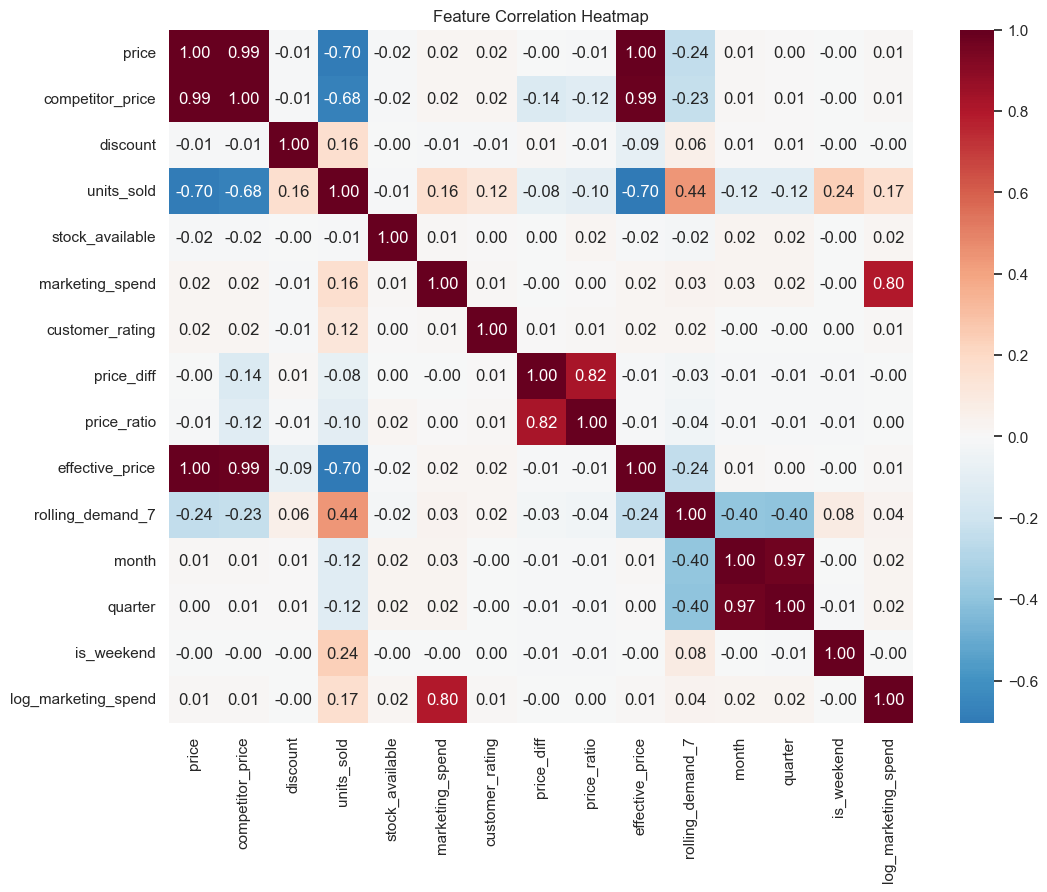

In [8]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,9))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation Analysis

- Price and competitor price show a strong positive correlation.  
- Units sold has a negative correlation with price, indicating higher prices reduce demand.  
- Discount and marketing spend have a slight positive impact on sales.  
- Engineered features like price_diff and price_ratio are also strongly correlated with pricing variables.  

**Insight:**  
Price-related features play a major role in determining demand, highlighting the importance of pricing strategies.

🔹 Cell 10: Day of Week Demand

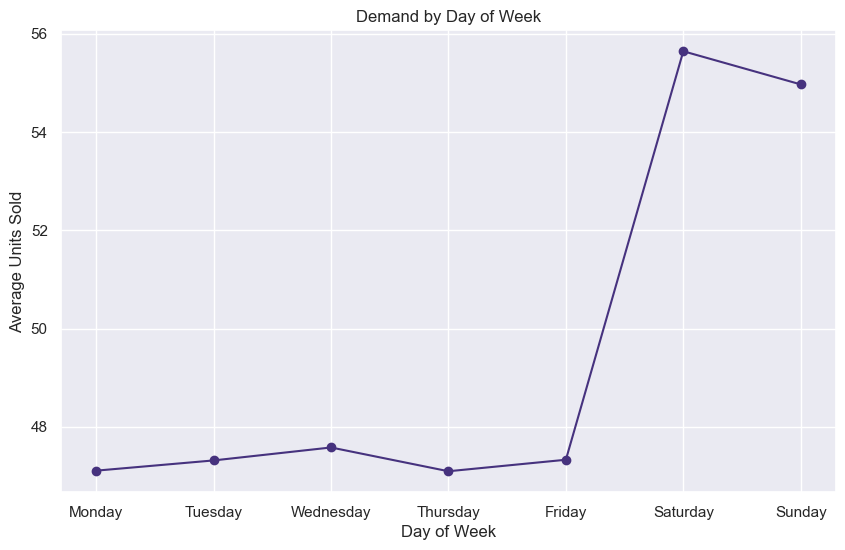

In [9]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_demand = df.groupby("day_of_week")["units_sold"].mean().reindex(day_order)

plt.figure(figsize=(10,6))

plt.plot(day_demand.index, day_demand.values, marker='o')

plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.title("Demand by Day of Week")
plt.grid(True)
plt.show()

### Demand by Day of Week

- Demand remains relatively stable during weekdays.  
- A significant increase in demand is observed on weekends (Saturday and Sunday).  
- This indicates higher customer activity during weekends.  

**Insight:**  
Weekend demand spikes suggest opportunities for targeted promotions and pricing strategies.

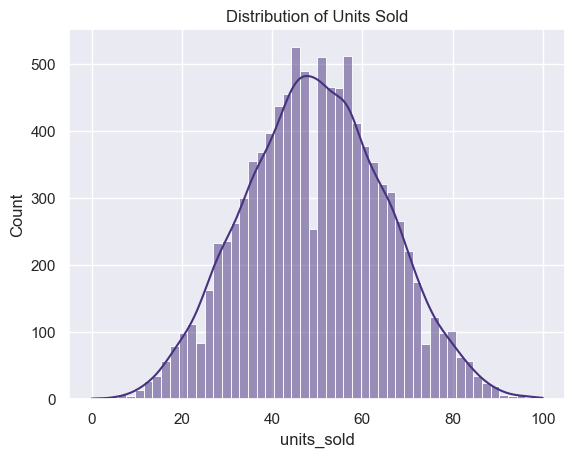

In [10]:
sns.histplot(df["units_sold"], kde=True)
plt.title("Distribution of Units Sold")
plt.show()

### Distribution of Units Sold

- The distribution appears approximately normal (bell-shaped).  
- Most sales values are concentrated around the mid-range.  
- There are fewer extreme values, indicating limited outliers.  

**Insight:**  
The target variable is well-distributed, which is suitable for regression modeling.

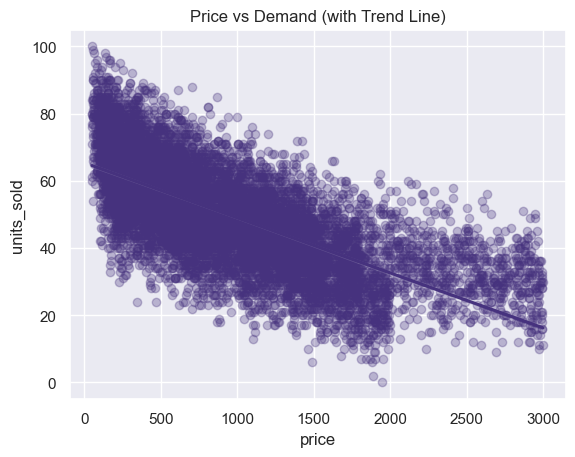

In [12]:
sns.regplot(x=df["price"], y=df["units_sold"], scatter_kws={'alpha':0.3})
plt.title("Price vs Demand (with Trend Line)")
plt.show()

### Price vs Demand (Trend Analysis)

- A clear negative relationship is observed between price and demand.  
- As price increases, units sold tend to decrease.  
- The regression line confirms this downward trend.  

**Insight:**  
This indicates strong price elasticity, where demand is sensitive to price changes.

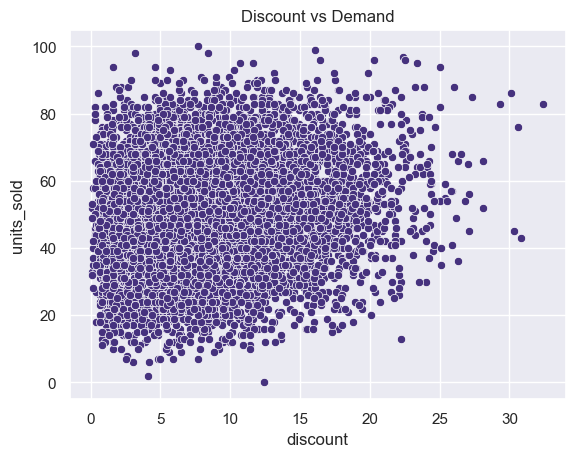

In [13]:
sns.scatterplot(x=df["discount"], y=df["units_sold"])
plt.title("Discount vs Demand")
plt.show()

### Discount vs Demand

- Demand generally increases with higher discounts.  
- The relationship is not perfectly linear but shows a positive trend.  
- Discounts help boost sales across different price levels.  

**Insight:**  
Promotional strategies like discounts play a key role in increasing demand.